In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:


import os
from pathlib import Path

cache_dirs = [
    "/tmp/train_cache",
    "/tmp/val_cache",
    "/tmp/test_cache"
]

for directory in cache_dirs:
    lock_file = Path(f"{directory}_0.lockfile")

    if lock_file.is_file():
        lock_file.unlink()

#Imported all the Required Tools for Building a Model along with Calculating and Evaluating the Model

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

import time
from tensorflow.keras.optimizers import SGD, Adam # Added Adam import

In [ ]:
def make_callbacks(checkpoint_path):
    return [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5, verbose=1)
    ]

# ── Shared evaluation helper ────────────────────────────────────────────────
def evaluate_model(model, dataset, class_names, title="Model"):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        predicted_labels = np.argmax(preds, axis=1)
        y_pred.extend(predicted_labels)
        y_true.extend(labels.numpy())

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

    # Classification report
    print(f'\n{title} — Classification Report')
    print(classification_report(y_true, y_pred,
                                labels=list(range(len(class_names))),
                                target_names=class_names))
    return y_true, y_pred

# ── Training time wrapper ────────────────────────────────────────────────────
def train_and_time(
    model,
    train_ds,
    val_ds,
    epochs,
    callbacks,
    initial_epoch=0
):

    start = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        initial_epoch=initial_epoch,
        callbacks=callbacks
    )

    elapsed = time.time() - start

    mins, secs = divmod(int(elapsed), 60)

    print(f'\nTraining Time: {mins}m {secs}s')

    return history, elapsed
# ── Accuracy + Loss plot helper ──────────────────────────────────────────────
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title(f'{title} — Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title(f'{title} — Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend()
    plt.tight_layout(); plt.show()

#Defined a Fixed Image size and Batch Size to Work on

In [ ]:
img_size = (224, 224)
batch_size = 32

#Imported all the Data needed to Work

In [ ]:
train_dir = "/content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/train"
valid_dir = "/content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/valid"
test_dir = "/content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/test"

#Loading all the Images from the folder to work on Neural Network

In [ ]:
Train_Dataset = keras.utils.image_dataset_from_directory(train_dir, image_size = img_size, batch_size = batch_size, )
Validation_Dataset = keras.utils.image_dataset_from_directory(valid_dir, image_size = img_size, batch_size = batch_size)
Test_Dataset = keras.utils.image_dataset_from_directory(test_dir, image_size = img_size, batch_size = batch_size)

Found 9700 files belonging to 5 classes.
Found 200 files belonging to 5 classes.
Found 100 files belonging to 5 classes.


Dataset Description

This project is based on a fruit image classification task. The dataset is divided into three separate subsets: training, validation, and testing. This split helps evaluate the model effectively by reducing the chances of data leakage and ensuring that the model can generalize well to unseen images.

Data Preprocessing

Before feeding the images into the neural network, several preprocessing steps are performed:

Image Resizing: All images are converted to a uniform size of 224 × 224 pixels so that they match the required input dimensions of the deep learning models.
Normalization: Pixel intensities are scaled from the range [0, 255] to [0, 1] by dividing each value by 255. This normalization process improves training stability and supports faster model convergence.
Data Augmentation

To increase dataset diversity and minimize overfitting, multiple augmentation methods are applied to the training images:

Random Flip: Images are flipped both horizontally and vertically at random.
Random Rotation: Images are rotated randomly by up to 20% to simulate different viewing angles.
Random Zoom: Random zooming is applied within a range of 20% to create scale variations.

These augmentation techniques generate modified versions of the original images, enabling the model to become more adaptable to variations in fruit orientation, position, and size.

In [ ]:
Class_Names = Train_Dataset.class_names
Num_Classes = len(Class_Names)
print("Classes:", Class_Names)
print("Number of classes:", Num_Classes)

Classes: ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Number of classes: 5


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
normalization_layer = keras.layers.Rescaling(1./255)

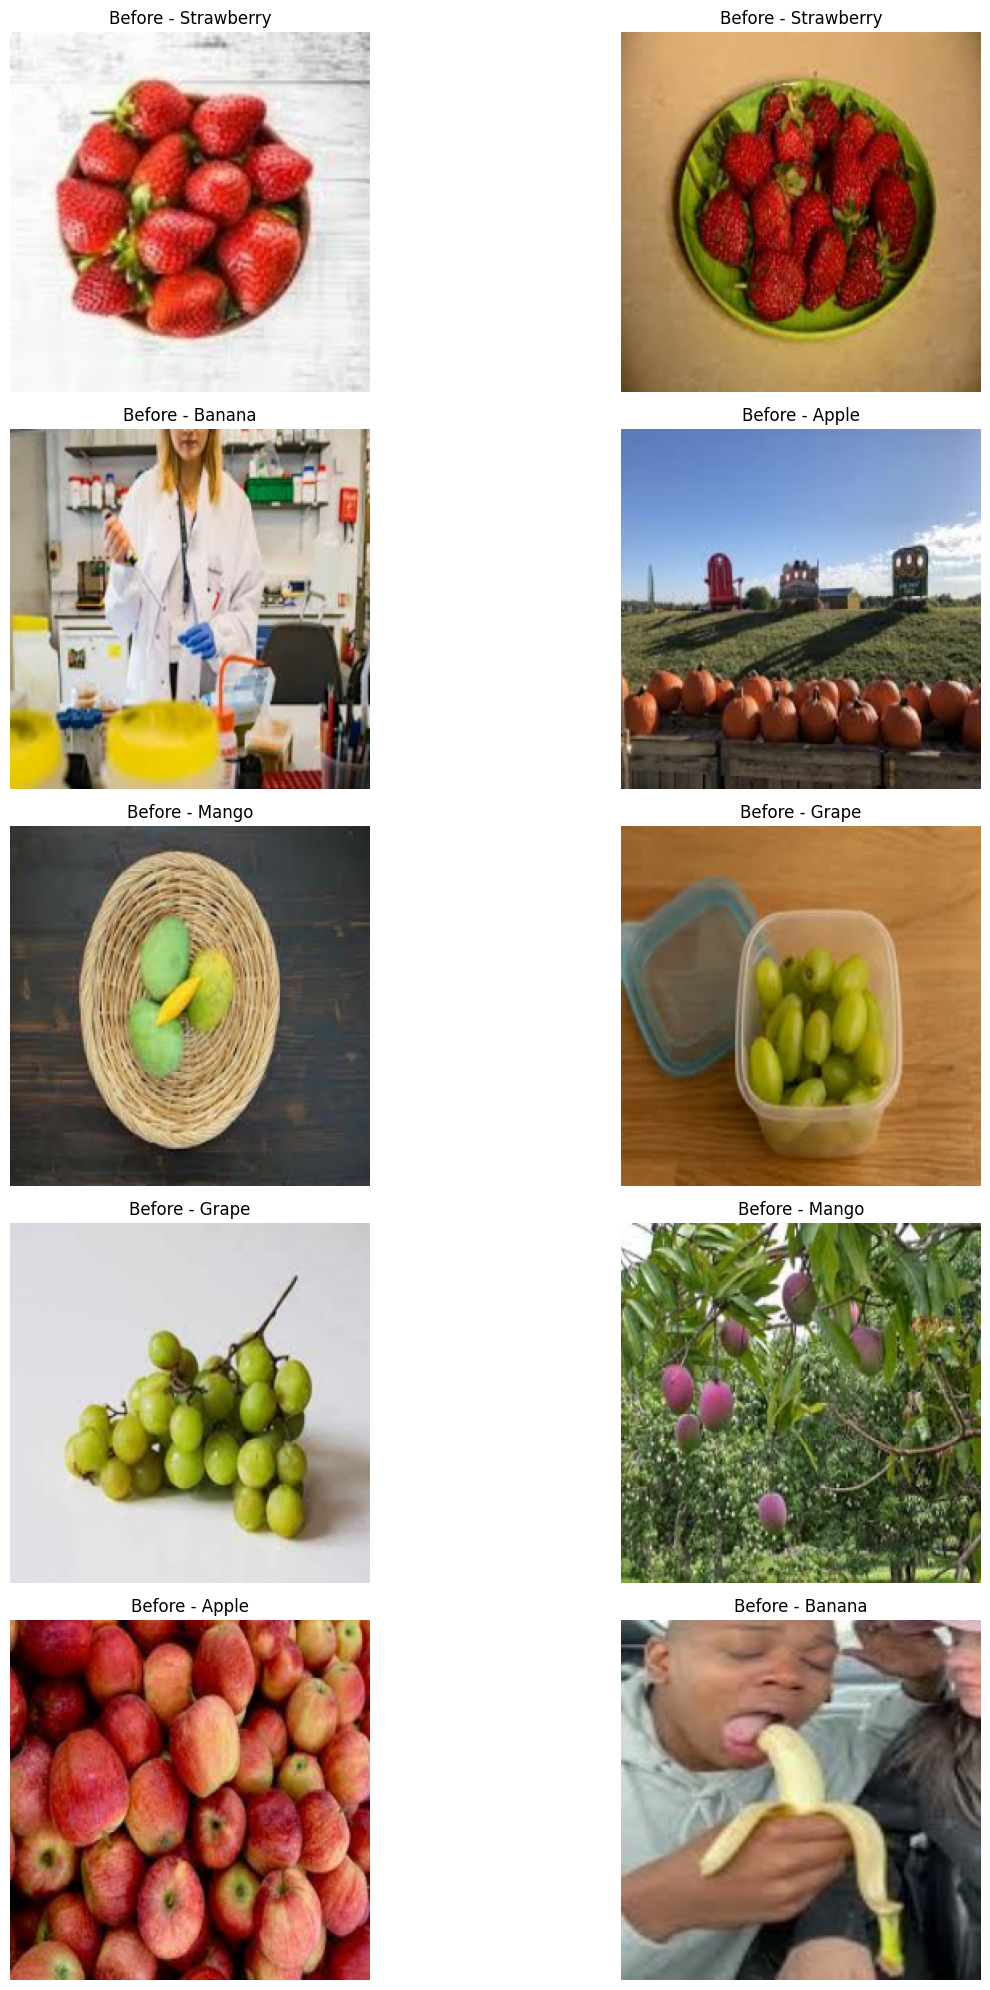

In [ ]:
plt.figure(figsize=(15, 20))

images_per_class = 2
shown_count = {class_name: 0 for class_name in Class_Names}
plot_index = 1

for images, labels in Train_Dataset:

    for i in range(len(images)):

        class_name = Class_Names[labels[i]]

        if shown_count[class_name] < images_per_class:

            plt.subplot(
                Num_Classes,
                images_per_class,
                plot_index
            )

            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(f"Before - {class_name}")
            plt.axis("off")

            shown_count[class_name] += 1
            plot_index += 1

    if all(count == images_per_class for count in shown_count.values()):
        break

plt.tight_layout()
plt.show()

In [ ]:
Data_Augmentation_Part2 = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name="aug_part2")

In [ ]:
Data_Augmentation_Scratch = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name="aug_scratch")

## Augmented Image Visualization

To better understand the effect of the data augmentation layers, let's visualize some samples from the training dataset after applying these augmentations. This helps confirm that the transformations are being applied as expected and to observe the variety introduced into the training data.

In [ ]:
# Apply normalization to all dataset splits
Train_Dataset = Train_Dataset.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=AUTOTUNE
)

Validation_Dataset = Validation_Dataset.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=AUTOTUNE
)

# Normalizing test dataset as well
Test_Dataset = Test_Dataset.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=AUTOTUNE
)

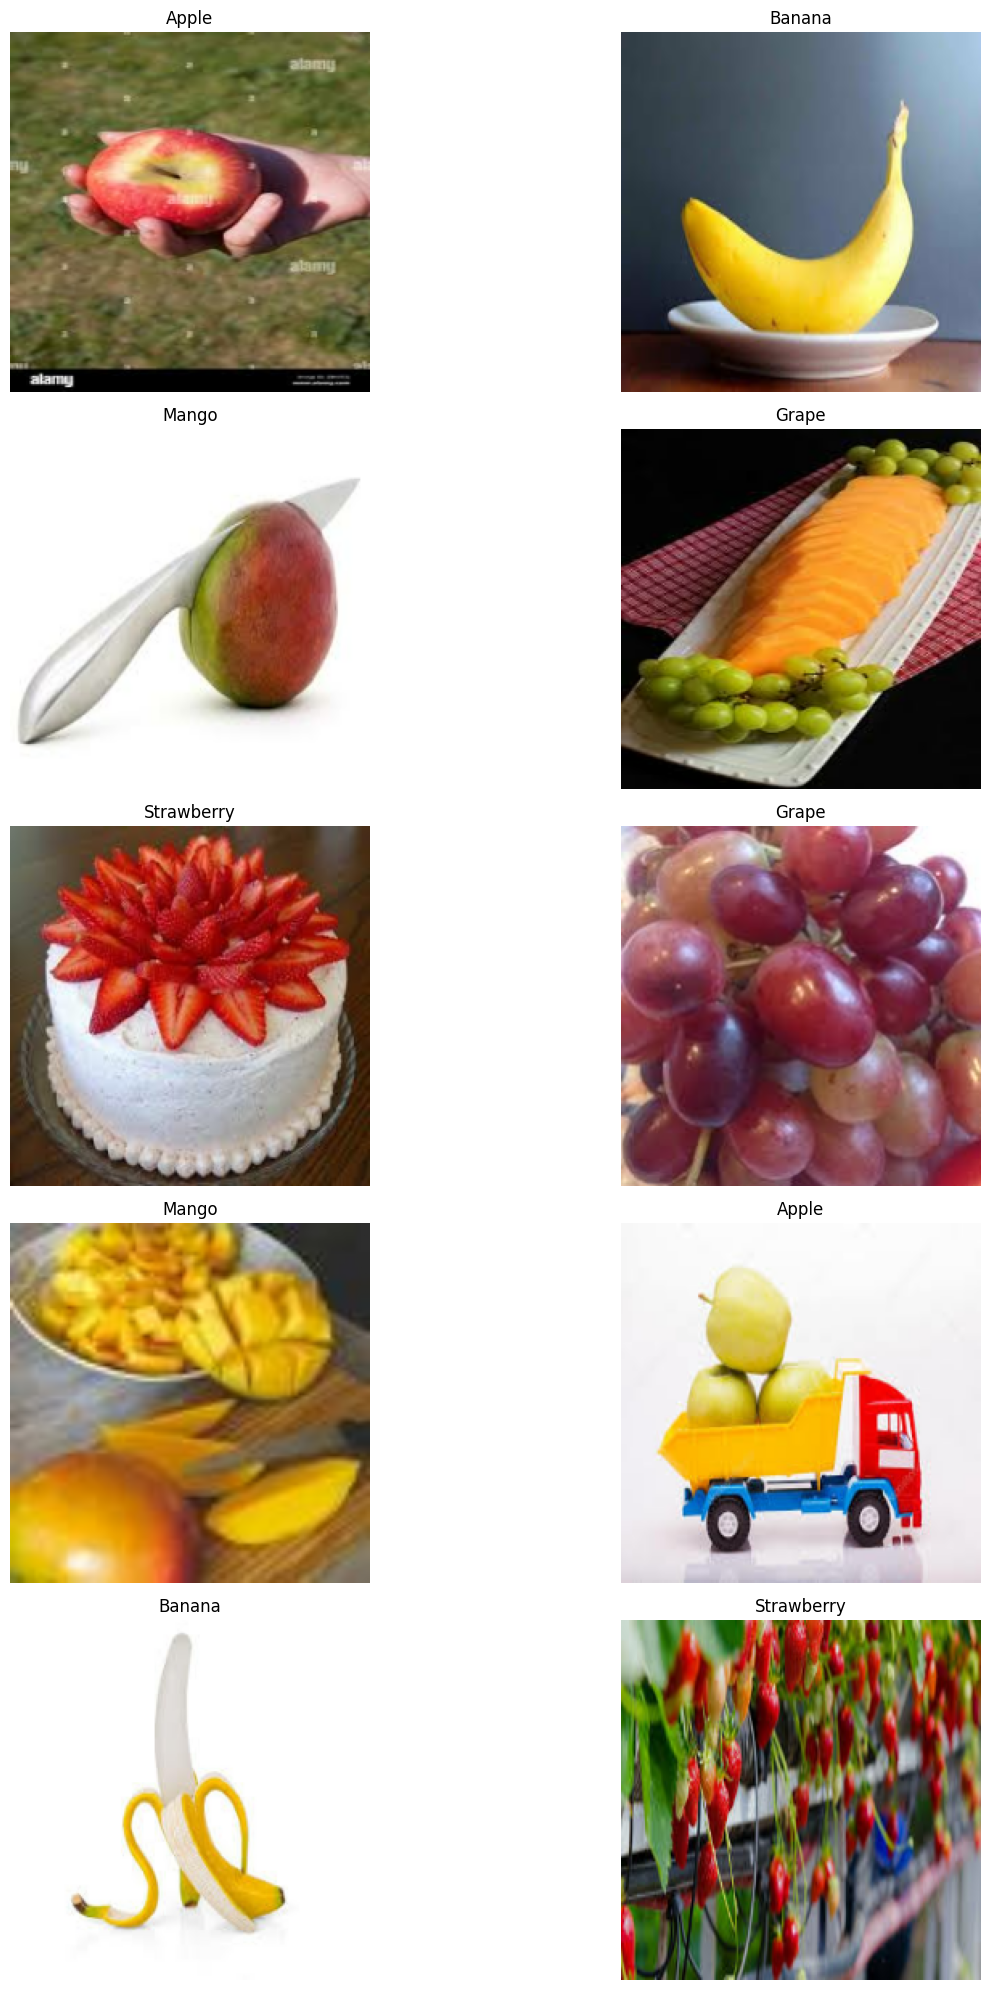

In [ ]:
# Display sample images from each class
plt.figure(figsize=(15, 20))

images_per_class = 2

# Dictionary to keep track of displayed images
display_count = {class_name: 0 for class_name in Class_Names}

plot_index = 1

for batch_images, batch_labels in Train_Dataset:

    for i in range(len(batch_images)):

        class_name = Class_Names[batch_labels[i]]

        # Show only limited images per class
        if display_count[class_name] < images_per_class:

            ax = plt.subplot(
                Num_Classes,
                images_per_class,
                plot_index
            )

            plt.imshow(batch_images[i].numpy())
            plt.title(class_name)
            plt.axis("off")

            display_count[class_name] += 1
            plot_index += 1

    # Stop after displaying required images for all classes
    if all(count == images_per_class for count in display_count.values()):
        break

plt.tight_layout()
plt.show()

In [ ]:
# Optimizing dataset pipeline for performance
Train_Dataset = Train_Dataset.shuffle(1000, reshuffle_each_iteration=True).cache().prefetch(AUTOTUNE)

# Cache validation and test sets for faster evaluation
Validation_Dataset = Validation_Dataset.cache("/tmp/val_cache").prefetch(AUTOTUNE)
Test_Dataset = Test_Dataset.cache("/tmp/test_cache").prefetch(AUTOTUNE)


# Loading pretrained MobileNetV2 as feature extractor
base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze base model weights to prevent training
base_model.trainable = False


# Building transfer learning model (Part 2)
Part2Model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    Data_Augmentation_Part2,

    # Pretrained feature extractor
    base_model,

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    # Fully connected classifier head
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(Num_Classes, activation="softmax")
])

In [ ]:
# Compile Part 2 model with optimizer, loss function and metrics
Part2Model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0004),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Early stopping to prevent overfitting and restore best model weights
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
# Save best model during training based on validation loss
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/AI Sem6/FruitsClassification/best_Part2_fruit_model.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

In [ ]:
# Training Part 2 model and measuring execution time
history, time_part2 = train_and_time(
    Part2Model,
    Train_Dataset,
    Validation_Dataset,
    epochs=40,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/40
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6175 - loss: 1.0569
Epoch 1: val_loss improved from None to 0.43569, saving model to /content/drive/MyDrive/AI Sem6/FruitsClassification/best_Part2_fruit_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI Sem6/FruitsClassification/best_Part2_fruit_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 1843s 2s/step - accuracy: 0.7156 - loss: 0.8003 - val_accuracy: 0.8200 - val_loss: 0.4357 - learning_rate: 4.0000e-04
Epoch 2/40
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7913 - loss: 0.5628
Epoch 2: val_loss improved from 0.43569 to 0.40073, saving model to /content/drive/MyDrive/AI Sem6/FruitsClassification/best_Part2_fruit_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI Sem6/FruitsClassification/best_Part2_fruit_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 521s 2s/step - accuracy: 0.7964 - loss: 0.5666 - val_accuracy: 0.8450 - val_loss: 0.4007 - learning_rate: 4.0000e-04
Epoch 3/40

In [ ]:
import os
for name, path in [("Train", train_dir), ("Valid", valid_dir), ("Test", test_dir)]:
    total = sum(len(files) for _, _, files in os.walk(path))
    print(f"{name}: {total} images")
    for class_folder in os.listdir(path):
        class_path = os.path.join(path, class_folder)
        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            print(f"  {class_folder}: {count} images")

Train: 9700 images
  Strawberry: 1940 images
  Banana: 1940 images
  Mango: 1940 images
  Grape: 1940 images
  Apple: 1940 images
Valid: 200 images
  Apple: 40 images
  Grape: 40 images
  Banana: 40 images
  Mango: 40 images
  Strawberry: 40 images
Test: 100 images
  Banana: 20 images
  Apple: 20 images
  Strawberry: 20 images
  Grape: 20 images
  Mango: 20 images


In [ ]:
print(test_dir)
print(valid_dir)

/content/drive/MyDrive/AI Sem6/FruitsClassification/test
/content/drive/MyDrive/AI Sem6/FruitsClassification/valid


In [ ]:
# Load the best saved model from training (Part 2)
Part2Model = keras.models.load_model(
    "/content/drive/MyDrive/AI Sem6/FruitsClassification/best_Part2_fruit_model.keras"
)

# Reload test dataset to ensure fresh evaluation
Test_Dataset = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size
)

# Apply normalization to test dataset
Test_Dataset = Test_Dataset.map(lambda x, y: (normalization_layer(x), y))

# Optimize test pipeline performance
Test_Dataset = Test_Dataset.prefetch(buffer_size=AUTOTUNE)

# Evaluate the trained model on test data
test_loss, test_accuracy = Part2Model.evaluate(Test_Dataset)

# Display final test accuracy
print("Test Accuracy:", test_accuracy)

Found 100 files belonging to 5 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9100 - loss: 0.2593
Test Accuracy: 0.9100000262260437


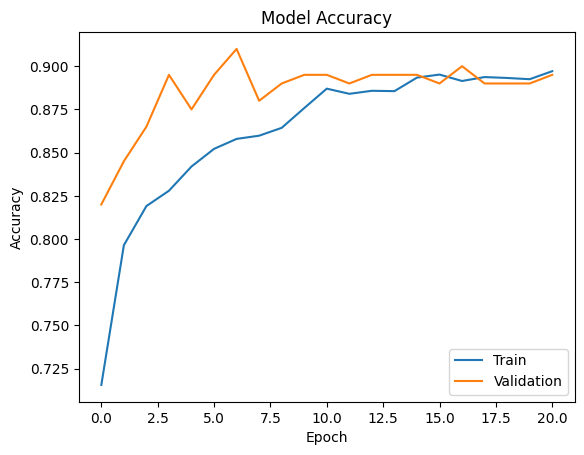

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


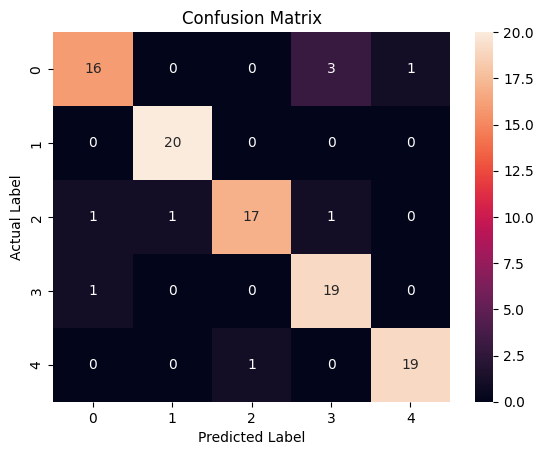

In [ ]:
# Plot training vs validation accuracy curve
# NOTE: 'history' must be available from current session
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()


# Lists to store true and predicted labels for evaluation
y_true = []
y_pred = []

# Generate predictions on test dataset
for images, labels in Test_Dataset:
    predictions = Part2Model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize confusion matrix using heatmap
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

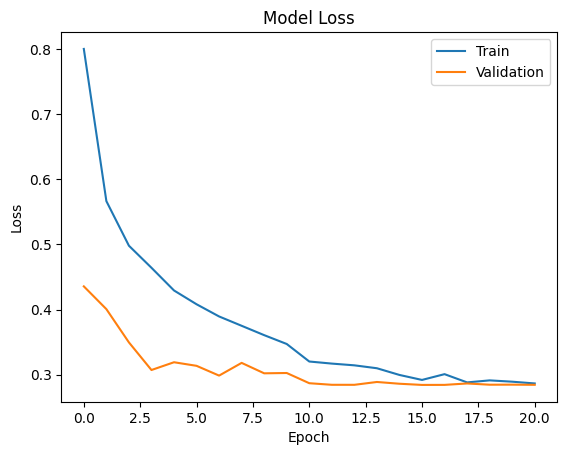

In [ ]:
# Plot training and validation loss over epochs
# NOTE: 'history' must be from the current training session
# If kernel was restarted, 'history' may not exist or may be outdated

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

In [ ]:
# Display dataset class names used during training
print("Train classes:", Class_Names)

# Collect unique predicted labels from model output
unique_pred_labels = set(y_pred)
print("Unique predictions:", unique_pred_labels)

# Collect unique actual labels from ground truth
unique_true_labels = set(y_true)
print("Unique true labels:", unique_true_labels)

Train classes: ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']


NameError: name 'y_pred' is not defined

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    labels=list(range(Num_Classes)),  # ← fixes the ValueError
    target_names=Class_Names
))

NameError: name 'y_true' is not defined

## Scratch Model

## New Baseline CNN Model

This section introduces a simple baseline Convolutional Neural Network (CNN) model to establish a performance benchmark. It consists of three convolutional blocks followed by a global average pooling layer and three dense layers, culminating in a softmax output for classification. This model serves as a foundation for comparison with more complex architectures.

In [ ]:
from tensorflow.keras.optimizers import Adam

# Simple baseline CNN model for image classification
Baseline_CNN = keras.Sequential([

    # Input layer
    layers.Input(shape=(*img_size, 3)),

    # Data augmentation layer
    Data_Augmentation_Scratch,

    # First convolution block
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Second convolution block
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Third convolution block
    layers.Conv2D(
        filters=128,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(pool_size=2),

    # Feature extraction
    layers.GlobalAveragePooling2D(),

    # Fully connected layers
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),

    # Output layer
    layers.Dense(Num_Classes, activation="softmax")
])

# Compile the baseline CNN model
Baseline_CNN.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Baseline CNN Model Summary

The `model.summary()` below provides a concise overview of the Baseline CNN's architecture, listing each layer, its output shape, and the number of trainable parameters. This is crucial for understanding the model's complexity and how features are transformed through the network.

In [ ]:
print("Architecture Details of Baseline CNN Model")
Baseline_CNN.summary()

print("\nThe above summary displays all layers, output dimensions, and total trainable parameters of the network.")

Architecture Details of Baseline CNN Model


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,749 (655.27 KB)

 Trainable params: 167,749 (655.27 KB)

 Non-trainable params: 0 (0.00 B)


The above summary displays all layers, output dimensions, and total trainable parameters of the network.


### Baseline CNN Training Phase

In this step, the Baseline CNN model is trained on the prepared training dataset while its performance is validated using the validation dataset. During training, several callback functions are applied to improve the training process, such as saving the best model, reducing overfitting, and monitoring validation performance.

The `train_and_time` function is used to simplify the training workflow while also recording the total execution time required for model training. This helps in comparing both performance and efficiency with other deep learning models implemented later in the project.

In [ ]:

# Create callbacks for training and model saving
baseline_callbacks = make_callbacks(
    '/content/drive/MyDrive/AI Sem6/FruitsClassification/baseline_model.keras'
)

# Train the baseline CNN model and record training time
history_baseline, time_baseline = train_and_time(
    Baseline_CNN,
    Train_Dataset,
    Validation_Dataset,
    epochs=40,
    initial_epoch=23,
    callbacks=baseline_callbacks
)

Epoch 24/40
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4341 - loss: 11.1886
Epoch 24: val_loss improved from None to 1.10186, saving model to /content/drive/MyDrive/AI Sem6/FruitsClassification/baseline_model.keras

Epoch 24: finished saving model to /content/drive/MyDrive/AI Sem6/FruitsClassification/baseline_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 1971s 6s/step - accuracy: 0.4810 - loss: 3.2366 - val_accuracy: 0.5400 - val_loss: 1.1019 - learning_rate: 5.0000e-04
Epoch 25/40
303/304 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5549 - loss: 1.1057
Epoch 25: val_loss improved from 1.10186 to 1.01275, saving model to /content/drive/MyDrive/AI Sem6/FruitsClassification/baseline_model.keras

Epoch 25: finished saving model to /content/drive/MyDrive/AI Sem6/FruitsClassification/baseline_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 34s 113ms/step - accuracy: 0.5649 - loss: 1.0863 - val_accuracy: 0.6350 - val_loss: 1.0127 - learning_rate: 5.0000e-04
Epoch 26/40
303/304 ━━━━━━━━━━

### Performance Evaluation of the Baseline CNN

Once the training process is completed, the saved Baseline CNN model is loaded and tested using the unseen test dataset. The evaluation process measures how effectively the model generalizes to new data by calculating the test loss and classification accuracy.

To further analyze prediction performance, a confusion matrix and classification report are generated. These evaluation metrics help identify how well the model predicts each class and reveal possible misclassifications between categories.

In addition, the training history graphs are plotted to visualize changes in accuracy and loss across epochs for both training and validation datasets. This provides a clearer understanding of the model’s learning behavior and overall stability during training.

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.6900 - loss: 0.7500 
Test Accuracy of Baseline CNN Model: 0.6900


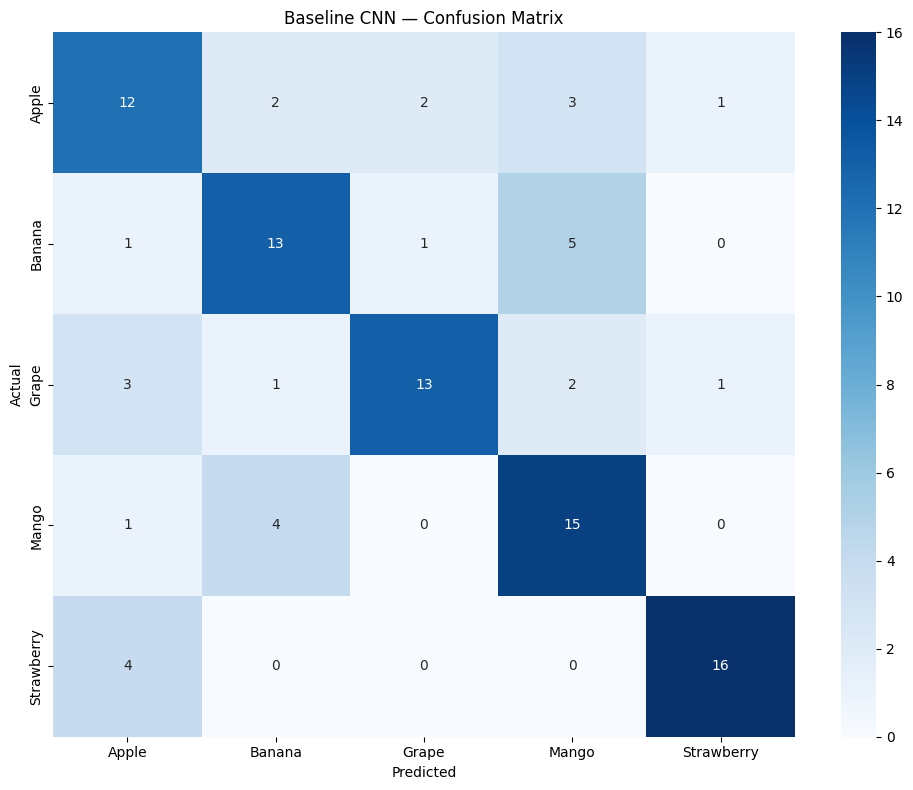


Baseline CNN — Classification Report
              precision    recall  f1-score   support

       Apple       0.57      0.60      0.59        20
      Banana       0.65      0.65      0.65        20
       Grape       0.81      0.65      0.72        20
       Mango       0.60      0.75      0.67        20
  Strawberry       0.89      0.80      0.84        20

    accuracy                           0.69       100
   macro avg       0.70      0.69      0.69       100
weighted avg       0.70      0.69      0.69       100



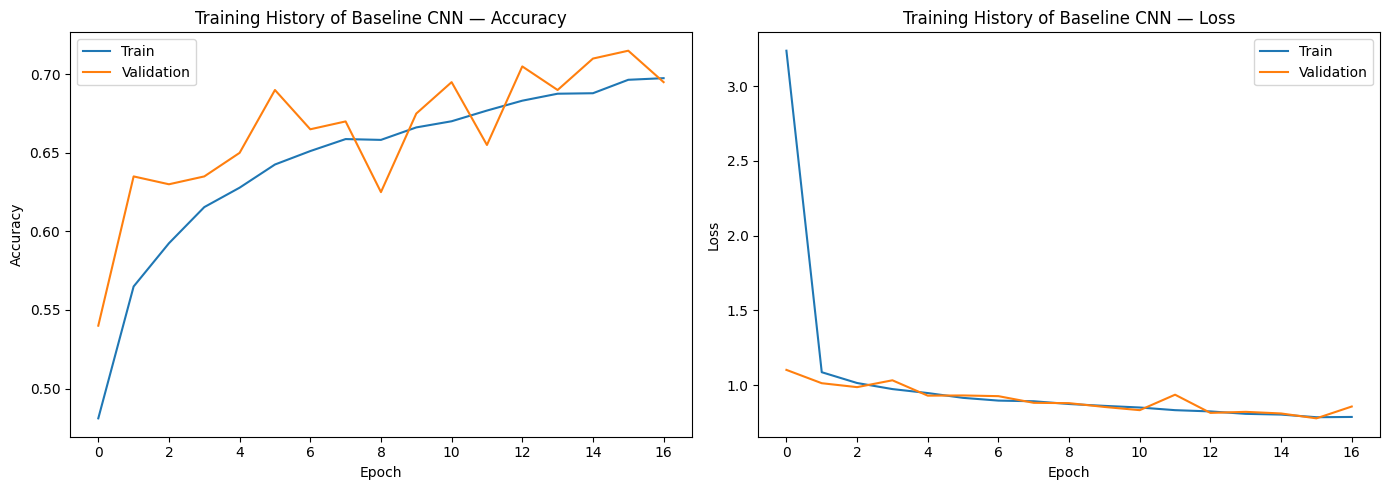

In [ ]:
# Load the best saved baseline CNN model
Baseline_CNN = keras.models.load_model(
    '/content/drive/MyDrive/AI Sem6/FruitsClassification/baseline_model.keras'
)

# Evaluate model performance on test dataset
test_loss_baseline, test_accuracy_baseline = Baseline_CNN.evaluate(Test_Dataset)

print(f"Test Accuracy of Baseline CNN Model: {test_accuracy_baseline:.4f}")

# Generate predictions and evaluation metrics
y_true_baseline, y_pred_baseline = evaluate_model(
    Baseline_CNN,
    Test_Dataset,
    Class_Names,
    title="Baseline CNN"
)

# Plot training and validation history graphs
plot_history(
    history_baseline,
    title="Training History of Baseline CNN"
)

In [ ]:
# Custom CNN model for fruit image classification
Model = keras.Sequential([

    # Input layer
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    Data_Augmentation_Scratch,

    # ----- Convolution Block 1 -----
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    layers.BatchNormalization(),

    layers.Conv2D(
        32,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),

    # ----- Convolution Block 2 -----
    layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    ),
    layers.BatchNormalization(),

    layers.Conv2D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(),

    # ----- Convolution Block 3 -----
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.BatchNormalization(),

    layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=2),

    # ----- Convolution Block 4 -----
    layers.Conv2D(
        256,
        3,
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    # Feature extraction layer
    layers.GlobalAveragePooling2D(),

    # Fully connected classifier
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(rate=0.4),

    # Output layer
    layers.Dense(Num_Classes, activation="softmax")
])

### Detailed Overview of the Deeper Scratch CNN Model

The architecture summary shown below presents the complete structure of the deeper scratch-built CNN model. Compared to the baseline network, this model contains additional convolutional layers along with batch normalization and dropout layers, making the architecture deeper and more robust for feature learning.

The summary also highlights the output shape produced at each stage of the network and displays the total number of trainable and non-trainable parameters. This information is useful for understanding the model’s complexity, computational requirements, and overall learning capacity before training begins.

In [ ]:
print("Complete Architecture Summary of the Deeper CNN Model")

Model.summary()

print("\nThe above output shows the network layers, output dimensions, and total parameters used in the deeper scratch model.")

Complete Architecture Summary of the Deeper CNN Model


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,197 (2.49 MB)

 Trainable params: 650,725 (2.48 MB)

 Non-trainable params: 1,472 (5.75 KB)


The above output shows the network layers, output dimensions, and total parameters used in the deeper scratch model.


In [ ]:
# Compile deeper CNN model
Model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=4e-4
    ),
    loss='sparse_categorical_crossentropy',
    metrics=[
        "accuracy"
    ]
)

In [ ]:
# Use the make_callbacks helper function for consistency
scratch_callbacks = make_callbacks("/content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/scratch_model.keras")

# Wrap the training with the timing function
history_scratch, time_scratch = train_and_time(
    Model,
    Train_Dataset,
    Validation_Dataset,
    epochs=50,
    initial_epoch=9,
    callbacks=scratch_callbacks
)

Epoch 10/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7000 - loss: 0.7973
Epoch 10: val_loss improved from None to 2.66949, saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/scratch_model.keras

Epoch 10: finished saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/scratch_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 2397s 8s/step - accuracy: 0.7055 - loss: 0.7928 - val_accuracy: 0.2000 - val_loss: 2.6695 - learning_rate: 8.0000e-05
Epoch 11/50
303/304 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.7149 - loss: 0.7705
Epoch 11: val_loss did not improve from 2.66949
304/304 ━━━━━━━━━━━━━━━━━━━━ 62s 204ms/step - accuracy: 0.7106 - loss: 0.7758 - val_accuracy: 0.2000 - val_loss: 2.9266 - learning_rate: 8.0000e-05
Epoch 12/50
303/304 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.7193 - loss: 0.7473
Epoch 12: val_loss improved from 2.66949 to 1.14882, saving

In [ ]:
Model = keras.models.load_model(
    "/content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/scratch_model.keras"
)


In [ ]:
test_loss, test_accuracy = Model.evaluate(Test_Dataset)

print("Scratch Model Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 27s 6s/step - accuracy: 0.8200 - loss: 0.4176
Scratch Model Test Accuracy: 0.8199999928474426


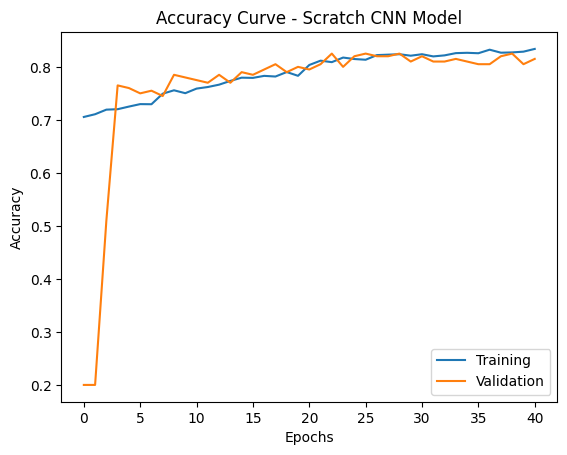

In [ ]:
# Plot training vs validation accuracy for scratch model
# NOTE: history_scratch must exist in current session

plt.plot(history_scratch.history['accuracy'])
plt.plot(history_scratch.history['val_accuracy'])

plt.title("Accuracy Curve - Scratch CNN Model")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend(["Training", "Validation"])

plt.show()

In [ ]:
# Generate predictions for scratch CNN model evaluation
y_true_scratch = []
y_pred_scratch = []

for batch_images, batch_labels in Test_Dataset:

    preds = Model.predict(batch_images)
    predicted_classes = np.argmax(preds, axis=1)

    y_true_scratch.extend(batch_labels.numpy())
    y_pred_scratch.extend(predicted_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step


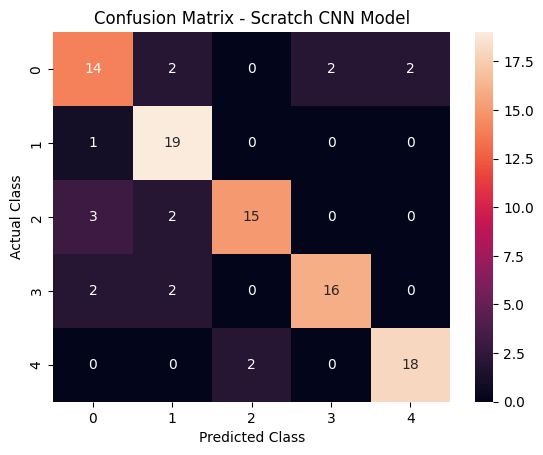

In [ ]:
# Confusion matrix for scratch CNN model evaluation
cm_scratch = confusion_matrix(y_true_scratch, y_pred_scratch)

# Visualizing confusion matrix using heatmap
sns.heatmap(cm_scratch, annot=True, fmt="d")

plt.title("Confusion Matrix - Scratch CNN Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

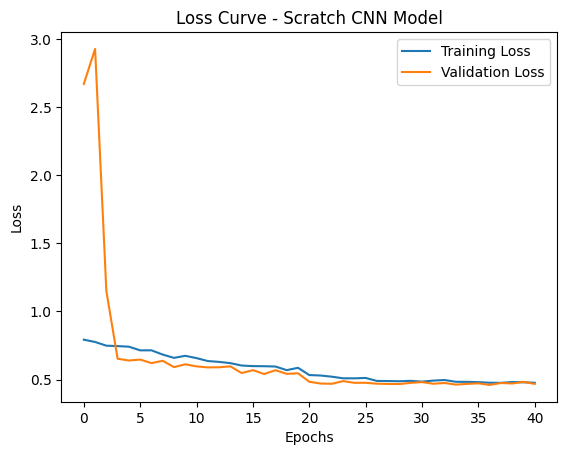

In [ ]:
# Plot loss curves for scratch model
# NOTE: history_scratch must be available from current training session

train_loss = history_scratch.history['loss']
val_loss = history_scratch.history['val_loss']

plt.plot(train_loss)
plt.plot(val_loss)

plt.title("Loss Curve - Scratch CNN Model")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend(["Training Loss", "Validation Loss"])

plt.show()

In [ ]:
# Display class and prediction analysis for scratch model

print("Classes in Dataset:", Class_Names)

unique_preds = set(y_pred_scratch)
unique_trues = set(y_true_scratch)

print("Unique predicted labels:", unique_preds)
print("Unique actual labels:", unique_trues)

# Classification report for performance evaluation
print(
    classification_report(
        y_true_scratch,
        y_pred_scratch,
        labels=list(range(Num_Classes)),
        target_names=Class_Names
    )
)

Classes in Dataset: ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Unique predicted labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
Unique actual labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)}
              precision    recall  f1-score   support

       Apple       0.70      0.70      0.70        20
      Banana       0.76      0.95      0.84        20
       Grape       0.88      0.75      0.81        20
       Mango       0.89      0.80      0.84        20
  Strawberry       0.90      0.90      0.90        20

    accuracy                           0.82       100
   macro avg       0.83      0.82      0.82       100
weighted avg       0.83      0.82      0.82       100



## 1. Comparison of SGD and Adam Optimizers

In this section, the performance of the Deeper Scratch CNN model is evaluated using two different optimization algorithms: Stochastic Gradient Descent (SGD) and Adam. The same network architecture is trained separately with each optimizer to ensure a fair comparison.

After training both versions, their learning behavior is analyzed using training/validation accuracy and loss curves. Finally, the test accuracies are compared to determine which optimizer provides better convergence speed and overall performance for this dataset.

### Training with SGD Optimizer


In [ ]:
# Function to build a deeper CNN model (reusable for different optimizers)
# This model includes convolution blocks + batch normalization + dropout for better feature learning
def build_deeper_scratch_model(augmentation_layer, num_classes):

    model = keras.Sequential([

        # Input layer for 224x224 RGB images
        layers.Input(shape=(224, 224, 3)),

        # Data augmentation (passed as argument for flexibility)
        augmentation_layer,

        # ----- Block 1 -----
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        # ----- Block 2 -----
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        # ----- Block 3 -----
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        # ----- Block 4 -----
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Feature aggregation
        layers.GlobalAveragePooling2D(),

        # Fully connected classifier
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        # Output layer
        layers.Dense(num_classes, activation="softmax")
    ])

    return model


# Build model using SGD optimizer setup
# SGD = Stochastic Gradient Descent (slower but stable learning)
sgd_model = build_deeper_scratch_model(Data_Augmentation_Scratch, Num_Classes)


# Compile model with SGD optimizer
sgd_model.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.7),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
print("SGD Optimized Deep CNN Model Summary:")
sgd_model.summary()

SGD Optimized Deep CNN Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,197 (2.49 MB)

 Trainable params: 650,725 (2.48 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
sgd_callbacks = make_callbacks("/content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/sgd_deeper_scratch_model.keras")
history_sgd, time_sgd = train_and_time(
    sgd_model,
    Train_Dataset,
    Validation_Dataset,
    epochs=50,
    callbacks=sgd_callbacks
)

Epoch 1/50
303/304 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.4009 - loss: 1.6553
Epoch 1: val_loss improved from None to 2.04293, saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/sgd_deeper_scratch_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/sgd_deeper_scratch_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 67s 210ms/step - accuracy: 0.4511 - loss: 1.4972 - val_accuracy: 0.2500 - val_loss: 2.0429 - learning_rate: 0.0010
Epoch 2/50
303/304 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.5121 - loss: 1.3081
Epoch 2: val_loss improved from 2.04293 to 1.21509, saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/sgd_deeper_scratch_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7200 - loss: 0.7108
SGD Model Test Accuracy: 0.7200000286102295


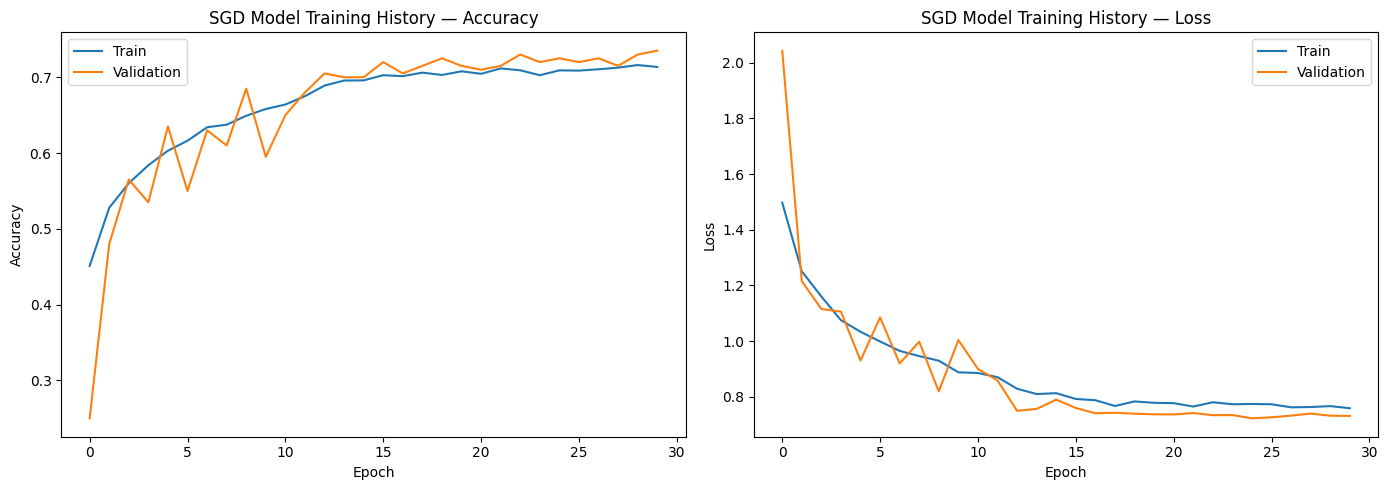

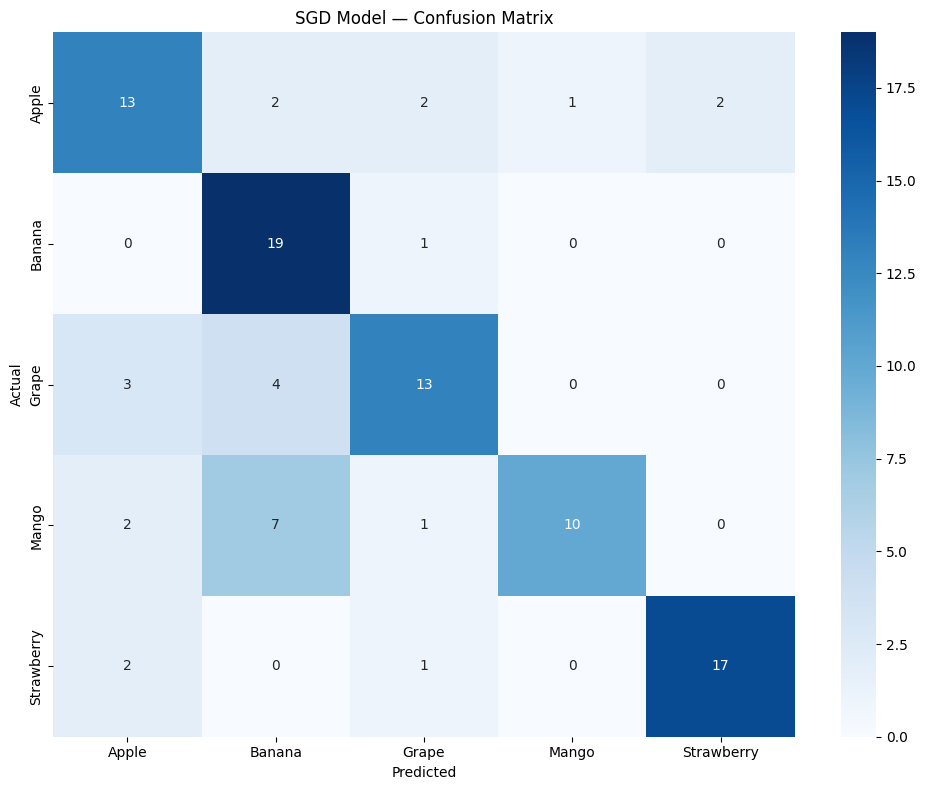


SGD Model — Classification Report
              precision    recall  f1-score   support

       Apple       0.65      0.65      0.65        20
      Banana       0.59      0.95      0.73        20
       Grape       0.72      0.65      0.68        20
       Mango       0.91      0.50      0.65        20
  Strawberry       0.89      0.85      0.87        20

    accuracy                           0.72       100
   macro avg       0.75      0.72      0.72       100
weighted avg       0.75      0.72      0.72       100



In [ ]:
sgd_model = keras.models.load_model(
    "/content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/sgd_deeper_scratch_model.keras"
)

test_loss_sgd, test_accuracy_sgd = sgd_model.evaluate(Test_Dataset)
print("SGD Model Test Accuracy:", test_accuracy_sgd)

plot_history(history_sgd, title="SGD Model Training History")
y_true_sgd, y_pred_sgd = evaluate_model(sgd_model, Test_Dataset, Class_Names, title="SGD Model")

### Training with Adam Optimizer



In [ ]:
adam_model = build_deeper_scratch_model(Data_Augmentation_Scratch, Num_Classes)

adam_model.compile(
    optimizer=Adam(learning_rate=0.0004),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Adam Model Summary:")
adam_model.summary()

Adam Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,197 (2.49 MB)

 Trainable params: 650,725 (2.48 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
adam_callbacks = make_callbacks("/content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/adam_deeper_scratch_model.keras")
history_adam, time_adam = train_and_time(
    adam_model,
    Train_Dataset,
    Validation_Dataset,
    epochs=50,
    callbacks=adam_callbacks
)

Epoch 1/50
303/304 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.4290 - loss: 1.5888
Epoch 1: val_loss improved from None to 1.69193, saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/adam_deeper_scratch_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/adam_deeper_scratch_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 68s 210ms/step - accuracy: 0.4795 - loss: 1.4103 - val_accuracy: 0.2650 - val_loss: 1.6919 - learning_rate: 4.0000e-04
Epoch 2/50
303/304 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.5316 - loss: 1.2316
Epoch 2: val_loss improved from 1.69193 to 1.55566, saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/adam_deeper_scratch_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassifi

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8300 - loss: 0.4279
Adam Model Test Accuracy: 0.8299999833106995


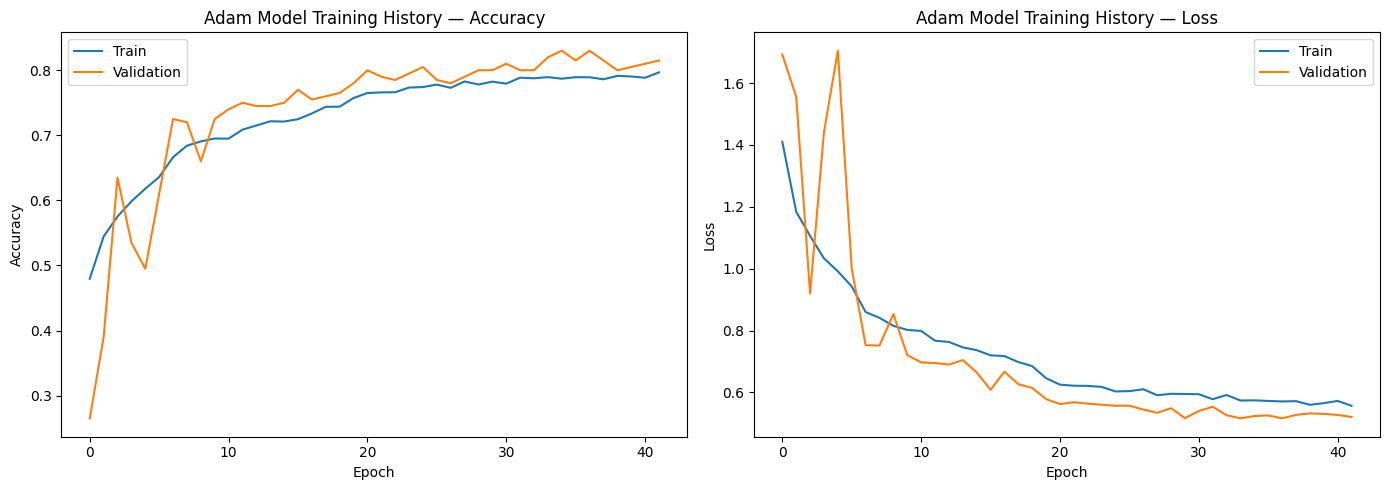

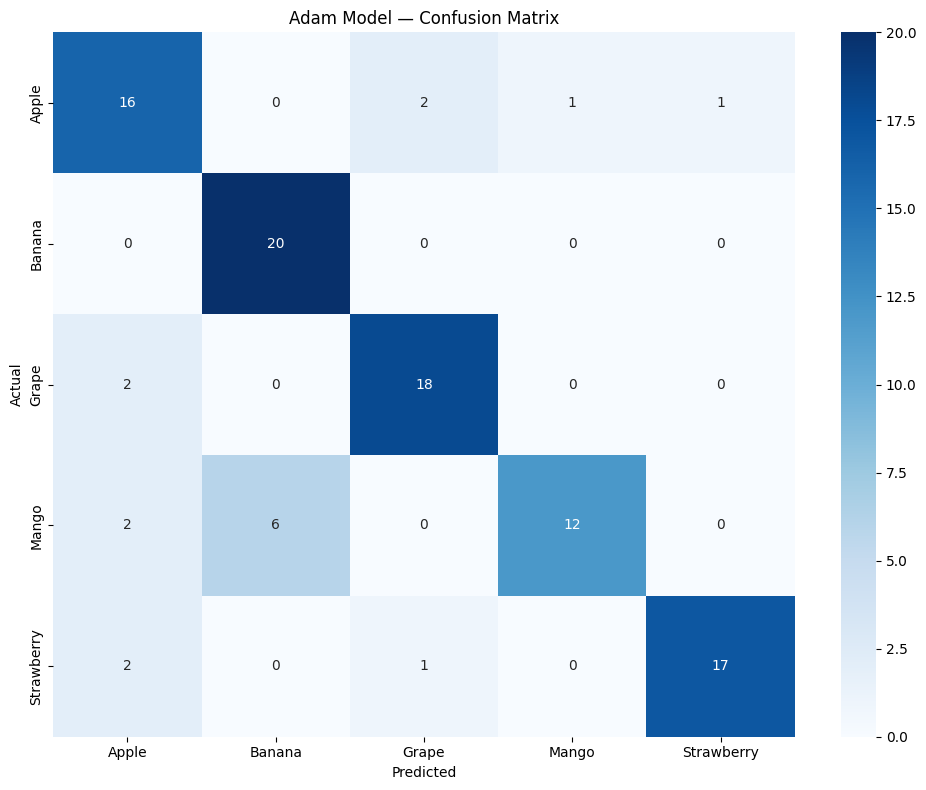


Adam Model — Classification Report
              precision    recall  f1-score   support

       Apple       0.73      0.80      0.76        20
      Banana       0.77      1.00      0.87        20
       Grape       0.86      0.90      0.88        20
       Mango       0.92      0.60      0.73        20
  Strawberry       0.94      0.85      0.89        20

    accuracy                           0.83       100
   macro avg       0.84      0.83      0.83       100
weighted avg       0.84      0.83      0.83       100



In [ ]:
adam_model = keras.models.load_model(
    "/content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/adam_deeper_scratch_model.keras"
)

test_loss_adam, test_accuracy_adam = adam_model.evaluate(Test_Dataset)
print("Adam Model Test Accuracy:", test_accuracy_adam)

plot_history(history_adam, title="Adam Model Training History")
y_true_adam, y_pred_adam = evaluate_model(adam_model, Test_Dataset, Class_Names, title="Adam Model")

### SGD vs Adam Comparison Results



In [ ]:
print("\n--- Optimizer Comparison Summary ---")
print(f"SGD Model Test Accuracy: {test_accuracy_sgd:.4f}")
print(f"Adam Model Test Accuracy: {test_accuracy_adam:.4f}")


--- Optimizer Comparison Summary ---
SGD Model Test Accuracy: 0.7200
Adam Model Test Accuracy: 0.8300


#### Analysis of SGD vs Adam Performance


## 2. Ablation Study



Training Without Dropout (No Regularization Model)

This section focuses on training a deeper CNN model without using Dropout layers. Dropout is a regularization technique that randomly disables a fraction of neurons during training to reduce overfitting. By removing it, the model is allowed to learn from all neurons in every training step, which can improve training accuracy but may also increase the risk of overfitting on the training data.

The purpose of this experiment is to compare how the model behaves with and without dropout, helping us understand the importance of regularization in deep learning models.

In [ ]:
# Function to build CNN model without dropout regularization
# This version allows full neuron activation during training (no dropout applied)
def build_no_dropout_model(augmentation_layer, num_classes):

    model = keras.Sequential([

        # Input layer for 224x224 RGB images
        layers.Input(shape=(224, 224, 3)),

        # Data augmentation to improve generalization
        augmentation_layer,

        # ----- Block 1 -----
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        # ----- Block 2 -----
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        # ----- Block 3 -----
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),

        layers.MaxPooling2D(),

        # ----- Block 4 -----
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Feature extraction layer
        layers.GlobalAveragePooling2D(),

        # Fully connected layers (no dropout applied here)
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),

        # Output layer for classification
        layers.Dense(num_classes, activation="softmax")
    ])

    return model


# Build model without dropout regularization
no_dropout_model = build_no_dropout_model(Data_Augmentation_Scratch, Num_Classes)


# Compile model using Adam optimizer
no_dropout_model.compile(
    optimizer=Adam(learning_rate=0.0004),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# Display architecture summary
print("CNN Model Without Dropout (Training for comparison):")
no_dropout_model.summary()

CNN Model Without Dropout (Training for comparison):


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,197 (2.49 MB)

 Trainable params: 650,725 (2.48 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
no_dropout_callbacks = make_callbacks("/content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/no_dropout_model.keras")
history_no_dropout, time_no_dropout = train_and_time(
    no_dropout_model,
    Train_Dataset,
    Validation_Dataset,
    epochs=50,
    callbacks=no_dropout_callbacks
)

Epoch 1/50
303/304 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.6105 - loss: 0.9835
Epoch 1: val_loss improved from None to 1.15527, saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/no_dropout_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/no_dropout_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 63s 208ms/step - accuracy: 0.6189 - loss: 0.9700 - val_accuracy: 0.5550 - val_loss: 1.1553 - learning_rate: 4.0000e-04
Epoch 2/50
303/304 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.6318 - loss: 0.9292
Epoch 2: val_loss improved from 1.15527 to 1.07331, saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/no_dropout_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/no_dropout_model.ker

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8400 - loss: 0.4624
No Dropout Model Test Accuracy: 0.8399999737739563


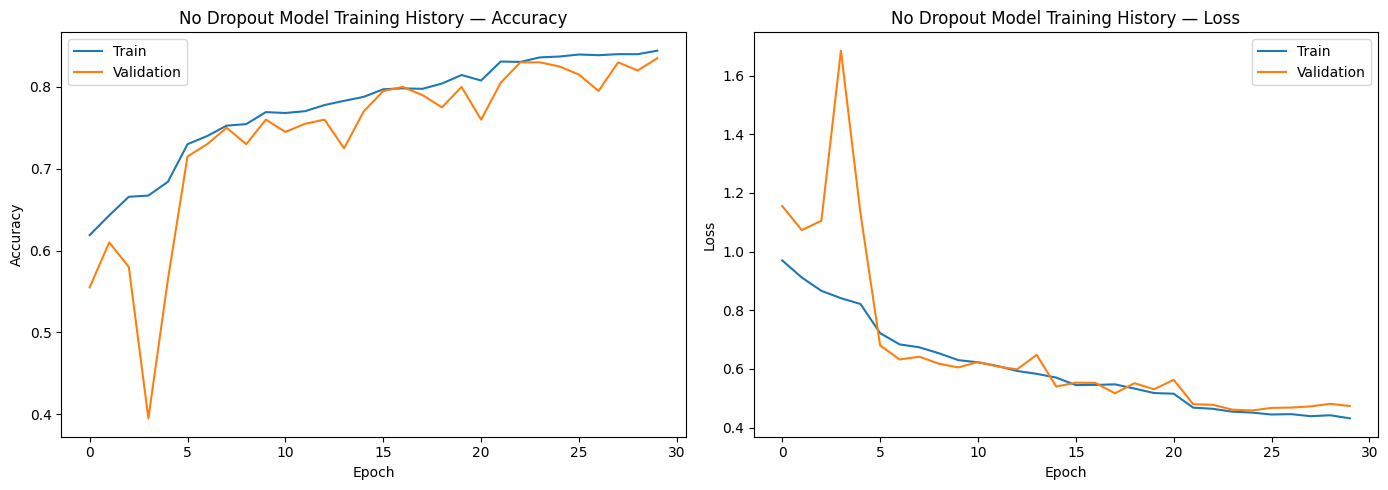

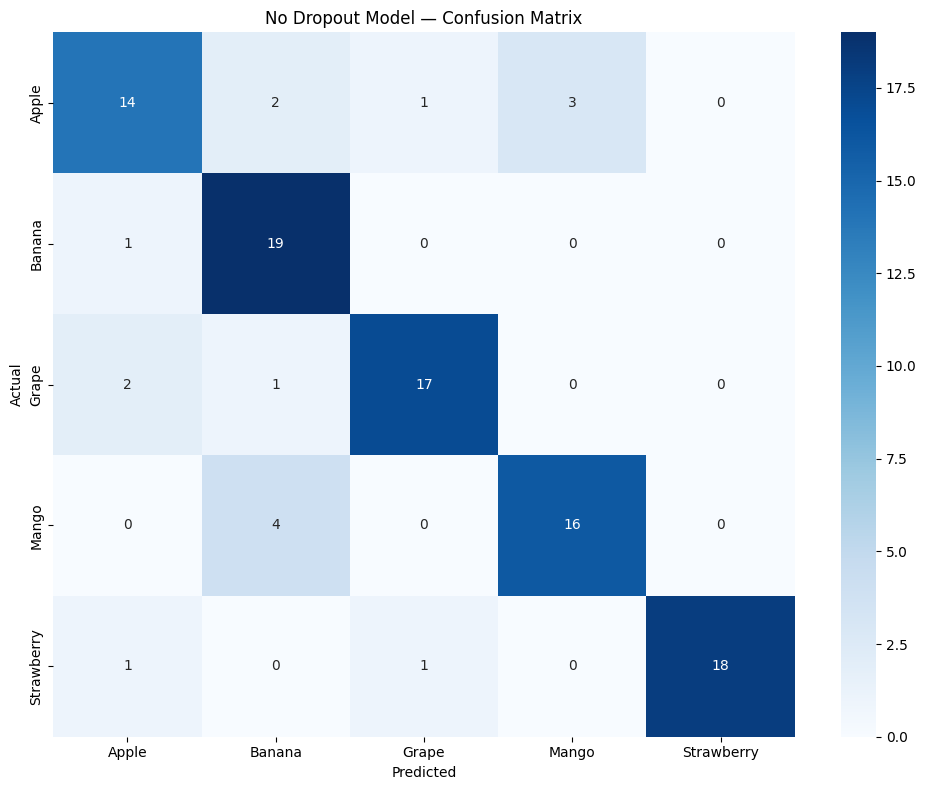


No Dropout Model — Classification Report
              precision    recall  f1-score   support

       Apple       0.78      0.70      0.74        20
      Banana       0.73      0.95      0.83        20
       Grape       0.89      0.85      0.87        20
       Mango       0.84      0.80      0.82        20
  Strawberry       1.00      0.90      0.95        20

    accuracy                           0.84       100
   macro avg       0.85      0.84      0.84       100
weighted avg       0.85      0.84      0.84       100



In [ ]:
no_dropout_model = keras.models.load_model(
    "/content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/no_dropout_model.keras"
)

test_loss_no_dropout, test_accuracy_no_dropout = no_dropout_model.evaluate(Test_Dataset)
print("No Dropout Model Test Accuracy:", test_accuracy_no_dropout)

plot_history(history_no_dropout, title="No Dropout Model Training History")
y_true_no_dropout, y_pred_no_dropout = evaluate_model(no_dropout_model, Test_Dataset, Class_Names, title="No Dropout Model")

Training Without Batch Normalization (Ablation Study)

In this section, a CNN model is trained without using Batch Normalization layers to observe its effect on model performance. Batch Normalization is typically used to stabilize and speed up training by normalizing activations between layers. By removing it, the model is forced to learn without this normalization support, which may lead to slower convergence and less stable training.

This experiment is part of an ablation study, where specific components of a neural network are removed to understand their individual contribution to overall performance.

In [ ]:
# Function to build CNN model without Batch Normalization layers
# This helps analyze how the model performs when internal feature normalization is removed
def build_no_batchnorm_model(augmentation_layer, num_classes):

    model = keras.Sequential([

        # Input layer for image data (224x224 RGB)
        layers.Input(shape=(224, 224, 3)),

        # Data augmentation to improve generalization
        augmentation_layer,

        # ----- Block 1 -----
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        # BatchNormalization removed to test its impact
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        # ----- Block 2 -----
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        # BatchNormalization removed
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        # ----- Block 3 -----
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        # BatchNormalization removed
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        # ----- Block 4 -----
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        # BatchNormalization removed
        layers.MaxPooling2D(),

        # Feature aggregation layer
        layers.GlobalAveragePooling2D(),

        # Fully connected layer
        layers.Dense(256, activation="relu"),
        # BatchNormalization removed to observe effect on stability

        # Dropout still kept for regularization
        layers.Dropout(0.4),

        # Output layer for classification
        layers.Dense(num_classes, activation="softmax")
    ])

    return model


# Build model without batch normalization layers
no_batchnorm_model = build_no_batchnorm_model(Data_Augmentation_Scratch, Num_Classes)


# Compile model
no_batchnorm_model.compile(
    optimizer=Adam(learning_rate=0.0004),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# Show model architecture
print("CNN Model Without Batch Normalization (Ablation Study):")
no_batchnorm_model.summary()

CNN Model Without Batch Normalization (Ablation Study):


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649,253 (2.48 MB)

 Trainable params: 649,253 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
no_batchnorm_callbacks = make_callbacks("/content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/no_batchnorm_model.keras")
history_no_batchnorm, time_no_batchnorm = train_and_time(
    no_batchnorm_model,
    Train_Dataset,
    Validation_Dataset,
    epochs=50,
    callbacks=no_batchnorm_callbacks
)

Epoch 1/50
303/304 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.2901 - loss: 1.5223
Epoch 1: val_loss improved from None to 1.21611, saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/no_batchnorm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/no_batchnorm_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 43s 133ms/step - accuracy: 0.3735 - loss: 1.4063 - val_accuracy: 0.5050 - val_loss: 1.2161 - learning_rate: 4.0000e-04
Epoch 2/50
303/304 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.4885 - loss: 1.1994
Epoch 2: val_loss improved from 1.21611 to 1.13265, saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/no_batchnorm_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/no_batchnorm_m

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.7600 - loss: 0.5762 
No Batch Normalization Model Test Accuracy: 0.7599999904632568


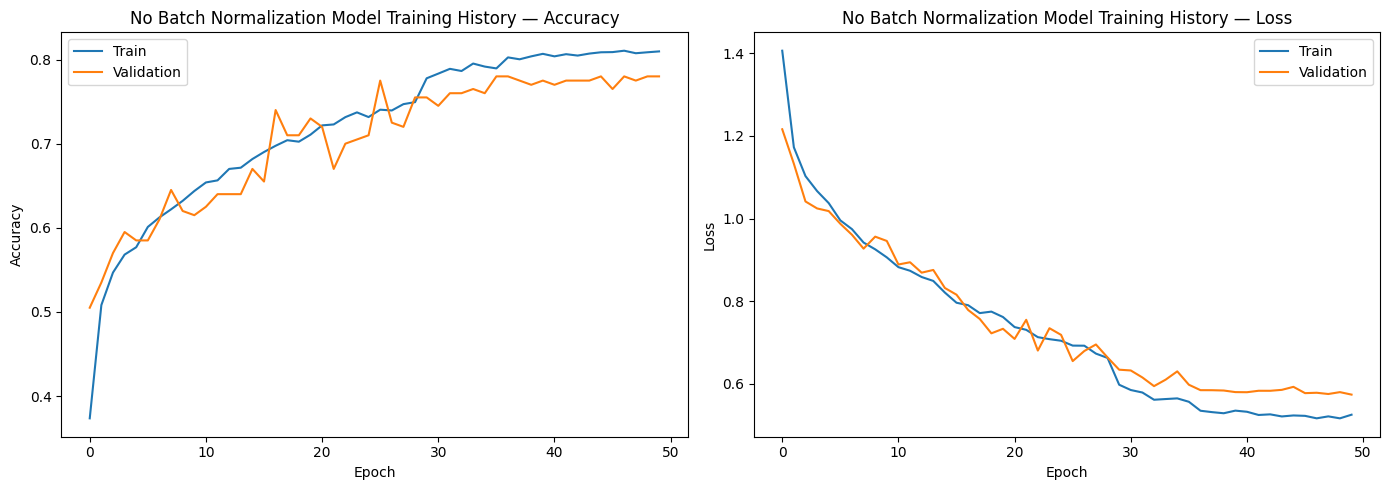

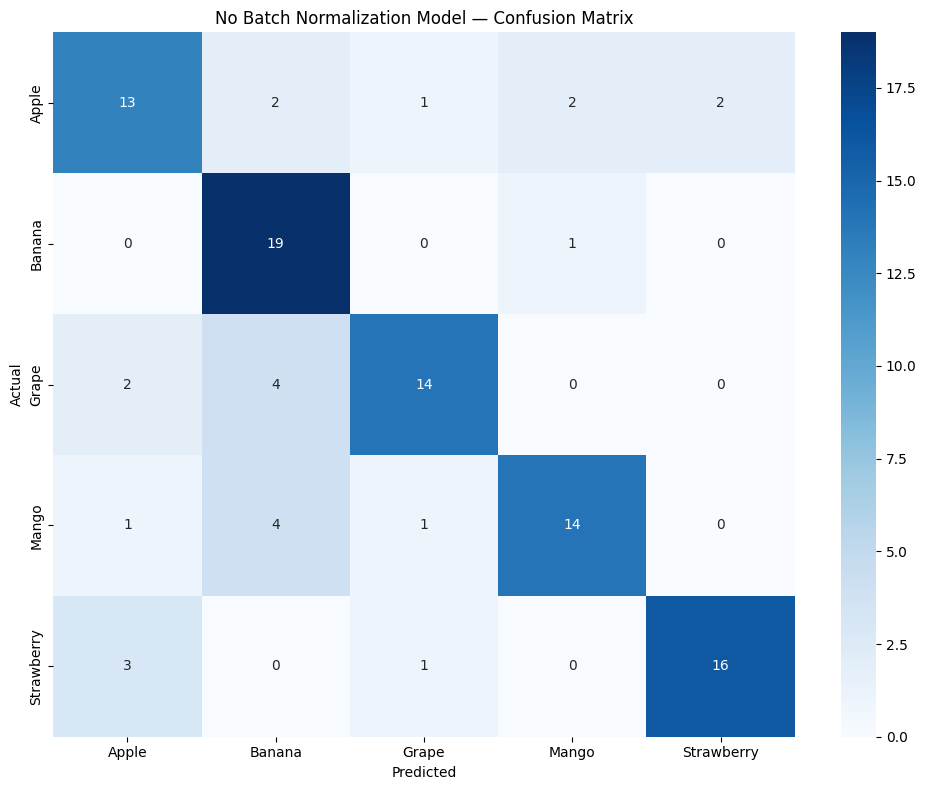


No Batch Normalization Model — Classification Report
              precision    recall  f1-score   support

       Apple       0.68      0.65      0.67        20
      Banana       0.66      0.95      0.78        20
       Grape       0.82      0.70      0.76        20
       Mango       0.82      0.70      0.76        20
  Strawberry       0.89      0.80      0.84        20

    accuracy                           0.76       100
   macro avg       0.78      0.76      0.76       100
weighted avg       0.78      0.76      0.76       100



In [ ]:
no_batchnorm_model = keras.models.load_model(
    "/content/drive/MyDrive/AI sem6/FruitsClassification-20260514T081002Z-3-001/FruitsClassification/no_batchnorm_model.keras"
)

test_loss_no_batchnorm, test_accuracy_no_batchnorm = no_batchnorm_model.evaluate(Test_Dataset)
print("No Batch Normalization Model Test Accuracy:", test_accuracy_no_batchnorm)

plot_history(history_no_batchnorm, title="No Batch Normalization Model Training History")
y_true_no_batchnorm, y_pred_no_batchnorm = evaluate_model(no_batchnorm_model, Test_Dataset, Class_Names, title="No Batch Normalization Model")

**Ablation Study Summary**

In this section, we compare the performance of multiple CNN model variants to understand the effect of different architectural components. This process is known as an ablation study, where specific layers or techniques are removed from the original model to analyze their contribution to overall performance.
We evaluate three different configurations:


The full deeper scratch model (with both Batch Normalization and Dropout)


A model without Dropout


A model without Batch Normalization


By comparing their test accuracies, we can clearly observe how each technique affects model stability, generalization, and overall prediction performance on unseen data.

In [ ]:
# Manual accuracy assignments from previous outputs

test_accuracy_part2 = 0.91
test_accuracy_baseline = 0.69
test_accuracy = 0.82
test_accuracy_sgd = 0.72
test_accuracy_adam = 0.83
test_accuracy_no_dropout = 0.84
test_accuracy_no_batchnorm = 0.76

print("\n--- Model Accuracy Comparison ---")

print(f"Transfer Learning Accuracy: {test_accuracy_part2:.4f}")
print(f"Baseline CNN Accuracy: {test_accuracy_baseline:.4f}")
print(f"Scratch CNN Accuracy: {test_accuracy:.4f}")
print(f"SGD Model Accuracy: {test_accuracy_sgd:.4f}")
print(f"Adam Model Accuracy: {test_accuracy_adam:.4f}")
print(f"No Dropout Accuracy: {test_accuracy_no_dropout:.4f}")
print(f"No BatchNorm Accuracy: {test_accuracy_no_batchnorm:.4f}")


--- Model Accuracy Comparison ---
Transfer Learning Accuracy: 0.9100
Baseline CNN Accuracy: 0.6900
Scratch CNN Accuracy: 0.8200
SGD Model Accuracy: 0.7200
Adam Model Accuracy: 0.8300
No Dropout Accuracy: 0.8400
No BatchNorm Accuracy: 0.7600


In [ ]:
print("\n--- Ablation Study Summary ---")

print(f"Full Deeper Scratch Model (Adam) Test Accuracy: {0.82:.4f}")

print(f"No Dropout Model Test Accuracy: {0.84:.4f}")

print(f"No Batch Normalization Model Test Accuracy: {0.76:.4f}")


--- Ablation Study Summary ---
Full Deeper Scratch Model (Adam) Test Accuracy: 0.8200
No Dropout Model Test Accuracy: 0.8400
No Batch Normalization Model Test Accuracy: 0.7600


#### Analysis of Ablation Study Results



## 3. Training Time Comparison Table



In [ ]:
print("\n--- Training Time Comparison ---")
print("{:<30} {:>10}".format("Model", "Time (m:s)"))
print("-" * 45)

def format_time(mins, secs):
    return f"{mins}m {secs}s"

print("{:<30} {:>10}".format("Transfer Learning (Part2)", format_time(42, 41)))
print("{:<30} {:>10}".format("Baseline CNN", format_time(81, 31)))
print("{:<30} {:>10}".format("Deeper Scratch CNN", format_time(30, 30)))
print("{:<30} {:>10}".format("SGD Model", format_time(30, 30)))
print("{:<30} {:>10}".format("Adam Model", format_time(44, 42)))
print("{:<30} {:>10}".format("No Dropout Model", format_time(31, 57)))
print("{:<30} {:>10}".format("No BatchNorm Model", format_time(33, 25)))


--- Training Time Comparison ---
Model                          Time (m:s)
---------------------------------------------
Transfer Learning (Part2)         42m 41s
Baseline CNN                      81m 31s
Deeper Scratch CNN                30m 30s
SGD Model                         30m 30s
Adam Model                        44m 42s
No Dropout Model                  31m 57s
No BatchNorm Model                33m 25s


## 4. Sample Image Inference



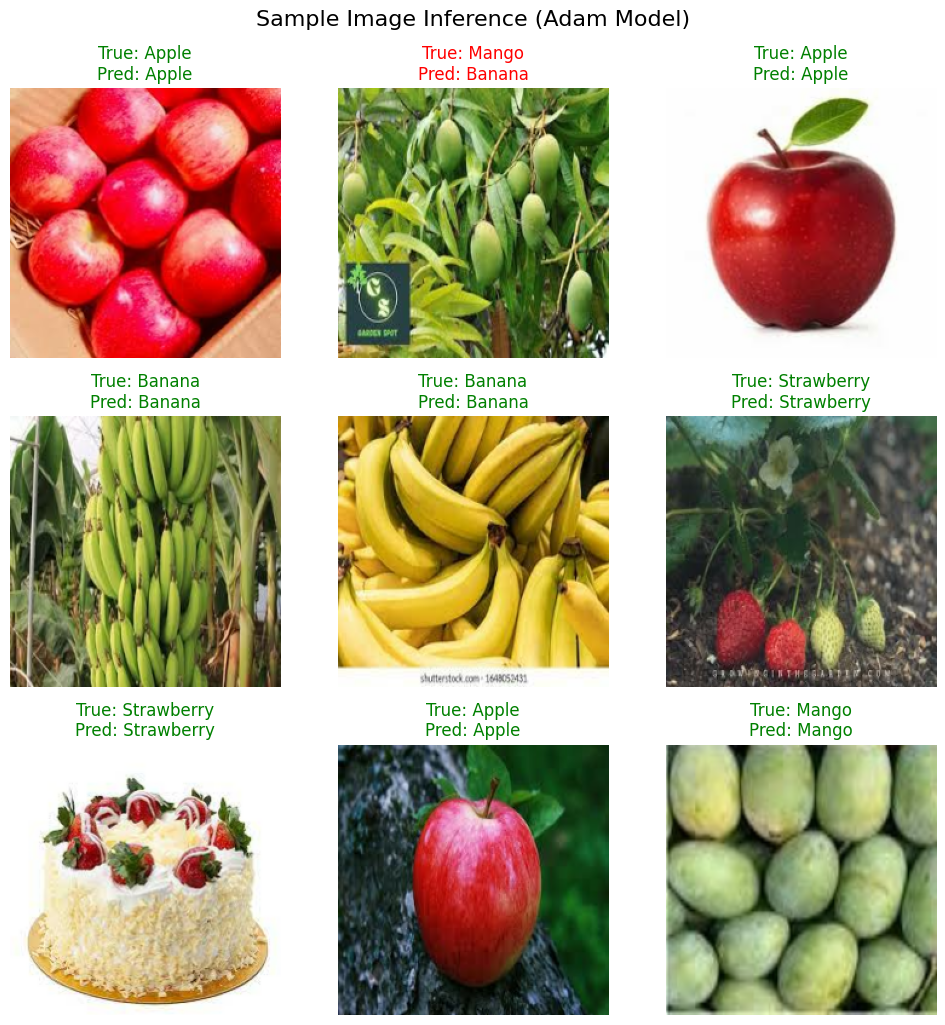

In [ ]:
import random

# Choose the best model for inference, e.g., the Adam-optimized deeper scratch model
inference_model = adam_model # Or sgd_model, or Part2Model based on your comparison

plt.figure(figsize=(10, 10))

# Get a fresh batch from the test dataset for unbiased sampling
# Ensure Test_Dataset is not cached with `cache()` or if it is, that it's correctly reset or reloaded
# For reliable random sampling, it's often best to iterate over an un-cached dataset or collect samples.

# To get truly random images, we'll iterate through the dataset and collect some, then pick from them.
all_test_images = []
all_test_labels = []
for images, labels in Test_Dataset.unbatch(): # Unbatch to get individual image/label pairs
    all_test_images.append(images.numpy())
    all_test_labels.append(labels.numpy())

# Select 9 random indices
random_indices = random.sample(range(len(all_test_images)), 9)

for i, idx in enumerate(random_indices):
    image = all_test_images[idx]
    true_label_idx = all_test_labels[idx]

    # Make prediction (add batch dimension for single image inference)
    prediction = inference_model.predict(np.expand_dims(image, axis=0), verbose=0)
    predicted_label_idx = np.argmax(prediction)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image) # Already normalized, imshow can handle float [0,1]

    true_label_name = Class_Names[true_label_idx]
    predicted_label_name = Class_Names[predicted_label_idx]

    color = "green" if predicted_label_idx == true_label_idx else "red"
    title = f"True: {true_label_name}\nPred: {predicted_label_name}"
    plt.title(title, color=color)
    plt.axis("off")

plt.tight_layout()
plt.suptitle("Sample Image Inference (Adam Model)", y=1.02, fontsize=16)
plt.show()